This notebook explores the closure quantities and u,v,w,p contours for different working boundary conditions.

| Working | Outlet velocity | Outlet pressure |      Other      |
| ------- | --------------- | --------------- | --------------- |
|    1    |     Neumann 0   |  Neumann 0      |        N/A      |
|    2    |     Neumann 0   |  Neumann 0      | p[top] - Dirichlet 0 |
|    3    |     f > 1e-6 ? Neumann 0 : Dirichlet 0   |  Neumann 0      |        N/A      |
|    4    |     f > 1e-6 ? Neumann 0 : Dirichlet 0   |  Neumann 0      |        p[bottom] = neumann(-$\rho_l g_z$)      |
|    5    |     f > 1e-6 ? Neumann 0 : Dirichlet 0   |  Neumann 0      |       u[top] =  p[top] = Dirichlet 0      |


In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from __future__ import annotations

import argparse
from collections.abc import Iterable
from dataclasses import dataclass
from pathlib import Path

In [2]:
def load_h5(filepath: str | Path, filename: str) -> dict[str, np.ndarray]:
    """
    Load all datasets from an HDF5 file.

    Parameters
    ----------
    filepath
        Directory containing the HDF5 file.

    filename
        Name of the HDF5 file, including the .h5 extension.

    Returns
    -------
    dict[str, np.ndarray]
        Dictionary containing all HDF5 datasets.

        The dictionary keys are the full dataset paths inside the
        HDF5 file. The values are NumPy arrays.

    Raises
    ------
    FileNotFoundError
        If the requested HDF5 file does not exist.

    OSError
        If the file exists but cannot be opened as an HDF5 file.
    """
    full_path = Path(filepath) / filename

    if not full_path.is_file():
        raise FileNotFoundError(
            f"HDF5 file was not found: {full_path.resolve()}"
        )

    data: dict[str, np.ndarray] = {}

    with h5py.File(full_path, mode="r") as h5_file:

        def load_dataset(name: str, obj: h5py.Dataset | h5py.Group) -> None:
            if isinstance(obj, h5py.Dataset):
                data[name] = obj[...]

        h5_file.visititems(load_dataset)

    return data

In [3]:
def compute_cell_centers(
    points: np.ndarray,
    topology: np.ndarray,
) -> np.ndarray:
    """
    Compute cell-center coordinates from mesh vertices and topology.

    Parameters
    ----------
    points
        Vertex coordinates with shape (n_points, n_dimensions).

    topology
        Cell connectivity with shape (n_cells, n_vertices_per_cell).
        Each row contains the vertex indices belonging to one cell.

    Returns
    -------
    np.ndarray
        Cell-center coordinates with shape (n_cells, n_dimensions).
    """
    points = np.asarray(points)
    topology = np.asarray(topology, dtype=np.int64)

    # Coordinates of every vertex belonging to every cell.
    # Shape:
    # (n_cells, n_vertices_per_cell, n_dimensions)
    cell_vertices = points[topology]

    # Average the vertex coordinates for each cell.
    cell_centers = cell_vertices.mean(axis=1)

    return cell_centers

In [4]:
def build_cartesian_cell_grid(
    cell_centers: np.ndarray,
    decimals: int = 12,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build Cartesian cell-center coordinate matrices.

    Parameters
    ----------
    cell_centers
        Cell-center coordinates with shape (n_cells, 2) or
        (n_cells, 3).

    decimals
        Number of decimal places used when identifying unique
        coordinates. This prevents floating-point roundoff from
        creating duplicate coordinate values.

    Returns
    -------
    x_matrix
        Cell-center x coordinates with shape (ny, nx).

    y_matrix
        Cell-center y coordinates with shape (ny, nx).

    sorting_indices
        Indices that reorder cell-based fields into matrix order.
    """
    cell_centers = np.asarray(cell_centers)

    x = cell_centers[:, 0]
    y = cell_centers[:, 1]

    x_rounded = np.round(x, decimals=decimals)
    y_rounded = np.round(y, decimals=decimals)

    unique_x = np.unique(x_rounded)
    unique_y = np.unique(y_rounded)

    nx = len(unique_x)
    ny = len(unique_y)

    if nx * ny != len(cell_centers):
        raise ValueError(
            "The cell centers do not form a complete Cartesian grid. "
            f"Found nx={nx}, ny={ny}, but nx*ny={nx * ny} and "
            f"n_cells={len(cell_centers)}."
        )

    # Primary sorting key: y
    # Secondary sorting key: x
    sorting_indices = np.lexsort((x_rounded, y_rounded))

    x_sorted = x[sorting_indices]
    y_sorted = y[sorting_indices]

    x_matrix = x_sorted.reshape(ny, nx)
    y_matrix = y_sorted.reshape(ny, nx)

    return x_matrix, y_matrix, sorting_indices

In [5]:
def vector_to_matrices(
    vector: np.ndarray,
    sorting_indices: np.ndarray,
    matrix_shape: tuple[int, int],
) -> tuple[np.ndarray, ...]:
    """
    Convert a cell-based vector field into component matrices.

    Parameters
    ----------
    vector
        Vector field with shape (n_cells, n_components).

    sorting_indices
        Sorting indices returned by build_cartesian_cell_grid().

    matrix_shape
        Desired matrix shape, normally x_matrix.shape.

    Returns
    -------
    tuple[np.ndarray, ...]
        One matrix for each vector component.
    """
    vector = np.asarray(vector)

    if vector.ndim != 2:
        raise ValueError(
            f"Expected vector shape (n_cells, n_components), "
            f"but received {vector.shape}."
        )

    if vector.shape[0] != len(sorting_indices):
        raise ValueError(
            f"Vector contains {vector.shape[0]} cells, but the mesh contains "
            f"{len(sorting_indices)} cells."
        )

    vector_sorted = vector[sorting_indices]

    return tuple(
        vector_sorted[:, component].reshape(matrix_shape)
        for component in range(vector.shape[1])
    )

In [6]:
def scalar_to_matrix(
    scalar: np.ndarray,
    sorting_indices: np.ndarray,
    matrix_shape: tuple[int, int],
) -> np.ndarray:
    """
    Convert a cell-based scalar field into a 2D Cartesian matrix.

    Parameters
    ----------
    scalar
        Scalar field with one value per cell.

    sorting_indices
        Sorting indices returned by build_cartesian_cell_grid().

    matrix_shape
        Desired matrix shape, normally x_matrix.shape.

    Returns
    -------
    np.ndarray
        Scalar field with shape (ny, nx).
    """
    scalar = np.asarray(scalar).squeeze()

    if scalar.ndim != 1:
        raise ValueError(
            f"Expected a one-dimensional scalar field after squeezing, "
            f"but received shape {scalar.shape}."
        )

    if len(scalar) != len(sorting_indices):
        raise ValueError(
            f"Scalar contains {len(scalar)} values, but the mesh contains "
            f"{len(sorting_indices)} cells."
        )

    return scalar[sorting_indices].reshape(matrix_shape)

The following functions are closure utilities aimed at using the cell-centered data to derive the required quantities.

In [7]:
def depth_integral(
    x: np.ndarray,
    y: np.ndarray,
    field: np.ndarray,
    *,
    lower_boundary: float = 0.0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Depth-integrate a cell-centered field along y at every x-location.

    Computes

        I(x) = integral field(x, y) dy

    using a finite-volume sum:

        I(x_i) = sum_j field[j, i] * dy[j, i]

    Parameters
    ----------
    x
        Cell-center x-coordinate matrix with shape (ny, nx).

    y
        Cell-center y-coordinate matrix with shape (ny, nx).

    field
        Cell-centered field with shape (ny, nx).

    lower_boundary
        Physical location of the lower boundary. For a wall at y = 0,
        use the default value 0.0.

    Returns
    -------
    x_locations
        One-dimensional array of x locations with shape (nx,).

    integral
        Depth-integrated field at every x location with shape (nx,).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    field = np.asarray(field, dtype=float)

    if x.ndim != 2 or y.ndim != 2 or field.ndim != 2:
        raise ValueError("x, y, and field must be two-dimensional arrays.")

    if x.shape != y.shape or x.shape != field.shape:
        raise ValueError(
            "x, y, and field must have identical shapes. "
            f"Received x={x.shape}, y={y.shape}, "
            f"field={field.shape}."
        )

    ny, nx = field.shape

    if ny < 2:
        raise ValueError(
            "At least two cells in the y-direction are required "
            "to reconstruct cell boundaries."
        )

    x_locations = x[0, :].copy()
    integral = np.zeros(nx, dtype=float)

    for i in range(nx):
        y_column = y[:, i]
        field_column = field[:, i]

        # Ensure cells are ordered from bottom to top.
        order = np.argsort(y_column)
        y_sorted = y_column[order]
        field_sorted = field_column[order]

        if np.any(np.diff(y_sorted) <= 0.0):
            raise ValueError(
                f"Repeated or non-increasing y coordinates found at "
                f"x-index {i}."
            )

        # Reconstruct cell-face locations from cell centers.
        y_faces = np.empty(ny + 1, dtype=float)

        # Physical lower wall.
        y_faces[0] = lower_boundary

        # Interior faces lie halfway between neighboring cell centers.
        y_faces[1:ny] = 0.5 * (
            y_sorted[:-1] + y_sorted[1:]
        )

        # Extrapolate the upper face by half the final center spacing.
        y_faces[ny] = (
            y_sorted[-1]
            + 0.5 * (y_sorted[-1] - y_sorted[-2])
        )

        cell_heights = np.diff(y_faces)

        if np.any(cell_heights <= 0.0):
            raise ValueError(
                f"Non-positive cell height reconstructed at x-index {i}."
            )

        integral[i] = np.sum(
            field_sorted * cell_heights
        )

    return x_locations, integral

In [8]:
def compute_wall_shear(
    x: np.ndarray,
    y: np.ndarray,
    u: np.ndarray,
    mu: float = 1.0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute lower-wall shear stress from a cell-centered velocity field.

    Assumptions
    -----------
    - Uniform Cartesian mesh.
    - Lower wall is located at y = 0.
    - No-slip condition: u_wall = 0.
    - Cell centers are located at:
          y_j = (j + 1/2) * dy

    Parameters
    ----------
    x, y : ndarray, shape (ny, nx)
        Cell-center coordinates.

    u : ndarray, shape (ny, nx)
        Streamwise velocity.

    mu : float
        Dynamic viscosity.

    order : 4
        Accuracy order of the wall-gradient stencil.

    Returns
    -------
    x_wall : ndarray, shape (nx,)
        Streamwise coordinates along the wall.

    tau_w : ndarray, shape (nx,)
        Wall shear stress:
            tau_w = mu * (du/dy)_wall
    """

    if x.shape != y.shape or x.shape != u.shape:
        raise ValueError("x, y, and u must have identical shapes.")

    if u.ndim != 2:
        raise ValueError("x, y, and u must be two-dimensional arrays.")

    required_cells = {2: 2, 3: 3, 4: 4}

    order = 4
    if u.shape[0] < required_cells[order]:
        raise ValueError(
            f"Order {order} requires at least "
            f"{required_cells[order]} wall-normal cells."
        )

    dy = y[1, 0] - y[0, 0]

    if dy <= 0.0:
        raise ValueError(
            "The y coordinate must increase away from the lower wall."
        )

    u1 = u[0, :]
    u2 = u[1, :]
    u3 = u[2, :]
    u4 = u[3, :]

    dudy_wall = (
        3675.0 * u1
        - 1225.0 * u2
        + 441.0 * u3
        - 75.0 * u4
    ) / (840.0 * dy)

    tau_w = mu * dudy_wall

    return x[0, :], tau_w

In [9]:
def compute_wall_shear_opt(
    x: np.ndarray,
    y: np.ndarray,
    u: np.ndarray,
    mu: float = 1.0,
    order: int = 4,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute lower-wall shear stress from a cell-centered velocity field.

    Assumptions
    -----------
    - Uniform Cartesian mesh.
    - Lower wall is located at y = 0.
    - No-slip condition: u_wall = 0.
    - Cell centers are located at:
          y_j = (j + 1/2) * dy

    Parameters
    ----------
    x, y : ndarray, shape (ny, nx)
        Cell-center coordinates.

    u : ndarray, shape (ny, nx)
        Streamwise velocity.

    mu : float
        Dynamic viscosity.

    order : {2, 3, 4}
        Accuracy order of the wall-gradient stencil.

    Returns
    -------
    x_wall : ndarray, shape (nx,)
        Streamwise coordinates along the wall.

    tau_w : ndarray, shape (nx,)
        Wall shear stress:
            tau_w = mu * (du/dy)_wall
    """

    if x.shape != y.shape or x.shape != u.shape:
        raise ValueError("x, y, and u must have identical shapes.")

    if u.ndim != 2:
        raise ValueError("x, y, and u must be two-dimensional arrays.")

    required_cells = {2: 2, 3: 3, 4: 4}

    if order not in required_cells:
        raise ValueError("order must be 2, 3, or 4.")

    if u.shape[0] < required_cells[order]:
        raise ValueError(
            f"Order {order} requires at least "
            f"{required_cells[order]} wall-normal cells."
        )

    dy = y[1, 0] - y[0, 0]

    if dy <= 0.0:
        raise ValueError(
            "The y coordinate must increase away from the lower wall."
        )

    u1 = u[0, :]
    u2 = u[1, :]

    if order == 2:
        dudy_wall = (
            9.0 * u1
            - u2
        ) / (3.0 * dy)

    elif order == 3:
        u3 = u[2, :]

        dudy_wall = (
            225.0 * u1
            - 50.0 * u2
            + 9.0 * u3
        ) / (60.0 * dy)

    else:
        u3 = u[2, :]
        u4 = u[3, :]

        dudy_wall = (
            3675.0 * u1
            - 1225.0 * u2
            + 441.0 * u3
            - 75.0 * u4
        ) / (840.0 * dy)

    tau_w = mu * dudy_wall

    return x[0, :], tau_w


In [10]:
def first_derivative_x2(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the first derivative of a one-dimensional field with respect to x.

    A second-order central-difference scheme is used at interior points.
    Second-order one-sided differences are used at the boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        One-dimensional x coordinates.

    field : ndarray, shape (nx,)
        Field values, such as h(x) or q(x).

    Returns
    -------
    dfield_dx : ndarray, shape (nx,)
        First derivative of the field with respect to x.

    Notes
    -----
    Interior stencil:

        df/dx |_i = (f[i+1] - f[i-1]) / (2*dx)

    Left boundary:

        df/dx |_0 = (-3*f[0] + 4*f[1] - f[2]) / (2*dx)

    Right boundary:

        df/dx |_{N-1}
            = (3*f[N-1] - 4*f[N-2] + f[N-3]) / (2*dx)

    The grid is assumed to be uniformly spaced.
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    if x.ndim != 1 or field.ndim != 1:
        raise ValueError("x and field must be one-dimensional arrays.")

    if x.shape != field.shape:
        raise ValueError("x and field must have the same shape.")

    if x.size < 3:
        raise ValueError(
            "At least three x points are required for the "
            "second-order boundary stencils."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError("x coordinates must increase monotonically.")

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid is not uniformly spaced. "
            "This function assumes constant dx."
        )

    dfield_dx = np.empty_like(field, dtype=float)

    # Interior points: second-order central difference
    dfield_dx[1:-1] = (
        field[2:] - field[:-2]
    ) / (2.0 * dx)

    # Left boundary: second-order forward difference
    dfield_dx[0] = (
        -3.0 * field[0]
        + 4.0 * field[1]
        - field[2]
    ) / (2.0 * dx)

    # Right boundary: second-order backward difference
    dfield_dx[-1] = (
        3.0 * field[-1]
        - 4.0 * field[-2]
        + field[-3]
    ) / (2.0 * dx)

    return dfield_dx

In [11]:
def first_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the first derivative of a one-dimensional field with respect to x.

    Fourth-order central differences are used in the interior.
    Fourth-order one-sided differences are used near the boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        One-dimensional uniformly spaced x coordinates.

    field : ndarray, shape (nx,)
        Field values, such as h(x) or q(x).

    Returns
    -------
    dfield_dx : ndarray, shape (nx,)
        Fourth-order approximation to df/dx.

    Notes
    -----
    Interior stencil:

        f'_i =
            (f[i-2] - 8*f[i-1] + 8*f[i+1] - f[i+2])
            / (12*dx)

    The grid must be uniformly spaced.

    At least 5 points are required.
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if x.ndim != 1 or field.ndim != 1:
        raise ValueError(
            "x and field must be one-dimensional arrays."
        )

    if x.shape != field.shape:
        raise ValueError(
            "x and field must have the same shape."
        )

    if x.size < 5:
        raise ValueError(
            "At least five x points are required for "
            "fourth-order differentiation."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid is not uniformly spaced. "
            "This function assumes constant dx."
        )

    dfield_dx = np.empty_like(field, dtype=float)

    # --------------------------------------------------------
    # Interior
    # Fourth-order central difference
    # --------------------------------------------------------

    dfield_dx[2:-2] = (
        field[:-4]
        - 8.0 * field[1:-3]
        + 8.0 * field[3:-1]
        - field[4:]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Left boundary
    # Fourth-order forward differences
    # --------------------------------------------------------

    dfield_dx[0] = (
        -25.0 * field[0]
        + 48.0 * field[1]
        - 36.0 * field[2]
        + 16.0 * field[3]
        - 3.0 * field[4]
    ) / (12.0 * dx)

    dfield_dx[1] = (
        -3.0 * field[0]
        - 10.0 * field[1]
        + 18.0 * field[2]
        - 6.0 * field[3]
        + field[4]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Right boundary
    # Fourth-order backward differences
    # --------------------------------------------------------

    dfield_dx[-2] = (
        -field[-5]
        + 6.0 * field[-4]
        - 18.0 * field[-3]
        + 10.0 * field[-2]
        + 3.0 * field[-1]
    ) / (12.0 * dx)

    dfield_dx[-1] = (
        3.0 * field[-5]
        - 16.0 * field[-4]
        + 36.0 * field[-3]
        - 48.0 * field[-2]
        + 25.0 * field[-1]
    ) / (12.0 * dx)

    return dfield_dx

In [12]:
# def second_derivative_x(
#     x: np.ndarray,
#     field: np.ndarray,
# ) -> np.ndarray:
#     """
#     Compute the second derivative of a one-dimensional field with
#     respect to x.

#     Uses:
#         - second-order central differences in the interior
#         - second-order one-sided differences at the boundaries

#     Parameters
#     ----------
#     x : ndarray (nx,)
#         Uniformly-spaced x coordinates.

#     field : ndarray (nx,)
#         Field values.

#     Returns
#     -------
#     d2field_dx2 : ndarray (nx,)
#         Second derivative.
#     """

#     x = np.asarray(x, dtype=float)
#     field = np.asarray(field, dtype=float)

#     if x.ndim != 1 or field.ndim != 1:
#         raise ValueError("x and field must be one-dimensional.")

#     if x.shape != field.shape:
#         raise ValueError("x and field must have the same shape.")

#     if x.size < 4:
#         raise ValueError(
#             "Need at least four points for the boundary stencil."
#         )

#     dx_values = np.diff(x)
#     dx = dx_values[0]

#     if not np.allclose(dx_values, dx):
#         raise ValueError("Grid must be uniformly spaced.")

#     d2field_dx2 = np.empty_like(field)

#     #
#     # Interior (second-order central)
#     #
#     d2field_dx2[1:-1] = (
#         field[2:]
#         - 2.0 * field[1:-1]
#         + field[:-2]
#     ) / dx**2

#     #
#     # Left boundary (second-order forward)
#     #
#     d2field_dx2[0] = (
#         2.0 * field[0]
#         - 5.0 * field[1]
#         + 4.0 * field[2]
#         - field[3]
#     ) / dx**2

#     #
#     # Right boundary (second-order backward)
#     #
#     d2field_dx2[-1] = (
#         2.0 * field[-1]
#         - 5.0 * field[-2]
#         + 4.0 * field[-3]
#         - field[-4]
#     ) / dx**2

#     return d2field_dx2

In [13]:
def second_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the second derivative of a one-dimensional field
    with respect to x.

    Uses:
        - fourth-order central differences in the interior
        - fourth-order one-sided differences near the boundaries

    Parameters
    ----------
    x : ndarray, shape (nx,)
        Uniformly spaced x coordinates.

    field : ndarray, shape (nx,)
        Field values.

    Returns
    -------
    d2field_dx2 : ndarray, shape (nx,)
        Fourth-order approximation to the second derivative.
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    if x.ndim != 1 or field.ndim != 1:
        raise ValueError(
            "x and field must be one-dimensional."
        )

    if x.shape != field.shape:
        raise ValueError(
            "x and field must have the same shape."
        )

    if x.size < 6:
        raise ValueError(
            "At least six points are required for "
            "fourth-order boundary stencils."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "Grid must be uniformly spaced."
        )

    d2field_dx2 = np.empty_like(
        field,
        dtype=float,
    )

    # --------------------------------------------------------
    # Interior: fourth-order central difference
    # --------------------------------------------------------

    d2field_dx2[2:-2] = (
        -field[4:]
        + 16.0 * field[3:-1]
        - 30.0 * field[2:-2]
        + 16.0 * field[1:-3]
        - field[:-4]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Left boundary
    # Fourth-order one-sided differences
    # --------------------------------------------------------

    d2field_dx2[0] = (
        45.0 * field[0]
        - 154.0 * field[1]
        + 214.0 * field[2]
        - 156.0 * field[3]
        + 61.0 * field[4]
        - 10.0 * field[5]
    ) / (12.0 * dx**2)

    d2field_dx2[1] = (
        10.0 * field[0]
        - 15.0 * field[1]
        - 4.0 * field[2]
        + 14.0 * field[3]
        - 6.0 * field[4]
        + field[5]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Right boundary
    # Mirror of left-boundary stencils
    # --------------------------------------------------------

    d2field_dx2[-2] = (
        field[-6]
        - 6.0 * field[-5]
        + 14.0 * field[-4]
        - 4.0 * field[-3]
        - 15.0 * field[-2]
        + 10.0 * field[-1]
    ) / (12.0 * dx**2)

    d2field_dx2[-1] = (
        -10.0 * field[-6]
        + 61.0 * field[-5]
        - 156.0 * field[-4]
        + 214.0 * field[-3]
        - 154.0 * field[-2]
        + 45.0 * field[-1]
    ) / (12.0 * dx**2)

    return d2field_dx2

In [14]:
def first_derivative_t(
    field: np.ndarray,
    field_minus: np.ndarray,
    time: float,
    time_minus: float,
) -> np.ndarray:
    """
    Compute the first-order time derivative using two snapshots.

    Parameters
    ----------
    field : ndarray
        Quantity at the current time.

    field_minus : ndarray
        Quantity at the previous time.

    time : float
        Current time.

    time_minus : float
        Previous time.

    Returns
    -------
    dfield_dt : ndarray
        Time derivative

            dfield_dt = (field - field_minus) / (time - time_minus)

        with the same shape as the input arrays.
    """

    field = np.asarray(field, dtype=float)
    field_minus = np.asarray(field_minus, dtype=float)

    if field.shape != field_minus.shape:
        raise ValueError(
            "field and field_minus must have identical shapes. "
            f"Received {field.shape} and {field_minus.shape}."
        )

    dt = float(time) - float(time_minus)

    if dt <= 0.0:
        raise ValueError(
            f"time must be greater than time_minus. "
            f"Received time={time}, time_minus={time_minus}."
        )

    return (field - field_minus) / dt

Main Code

In [15]:
t = 1100

parent_dir = Path("/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/codes/basilisk/physics-tests/blowup-fix/O2-change")

case_names = [
    "working1",
    "working2",
    "working3",
    "working4",
]

all_case_data = {}

for case_name in case_names:

    case_dir = parent_dir / case_name

    output_dir = case_dir / "output"
    interface_dir = case_dir / "infc"

    snapshot_filename = f"snapshot_{t:06.0f}.h5"
    interface_filename = f"interface_{t:06.0f}.h5"
    interface_minus_filename = f"interface_minus_{t:06.0f}.h5"

    snapshot_path = output_dir / snapshot_filename
    interface_path = interface_dir / interface_filename
    interface_minus_path = interface_dir / interface_minus_filename

    required_files = [
        snapshot_path,
        interface_path,
        interface_minus_path,
    ]

    missing_files = [path for path in required_files if not path.is_file()]

    if missing_files:
        print(f"\nSkipping {case_name}")

        for path in missing_files:
            print(f"  Missing: {path}")

        continue

    flowfield_data = load_h5(
        output_dir,
        snapshot_filename,
    )

    interface_data = load_h5(
        interface_dir,
        interface_filename,
    )

    interface_minus_data = load_h5(
        interface_dir,
        interface_minus_filename,
    )

    all_case_data[case_name] = {
        "case_dir": case_dir,
        "flowfield": flowfield_data,
        "interface": interface_data,
        "interface_minus": interface_minus_data,
    }

    print(f"Loaded: {case_name}")

Loaded: working1
Loaded: working2
Loaded: working3
Loaded: working4


In [16]:
case_name = "working3"

flowfield_data = all_case_data[case_name]["flowfield"]
interface_data = all_case_data[case_name]["interface"]
interface_minus_data = all_case_data[case_name]["interface_minus"]

In [17]:
print("Loaded cases:")

for case_name in all_case_data:
    print(f"  {case_name}")

Loaded cases:
  working1
  working2
  working3
  working4


In [18]:
print("Snapshot datasets:")
for key, value in flowfield_data.items():
    print(f"  {key:<35} shape={value.shape}, dtype={value.dtype}")

Snapshot datasets:
  Cells/d                             shape=(2097152, 1), dtype=float64
  Cells/d_minus                       shape=(2097152, 1), dtype=float64
  Cells/f                             shape=(2097152, 1), dtype=float64
  Cells/f_minus                       shape=(2097152, 1), dtype=float64
  Cells/p                             shape=(2097152, 1), dtype=float64
  Cells/p_minus                       shape=(2097152, 1), dtype=float64
  Cells/u.x                           shape=(2097152, 3), dtype=float64
  Cells/u_minus.x                     shape=(2097152, 3), dtype=float64
  Geometry/Points                     shape=(2113665, 3), dtype=float64
  Parameters/Ca                       shape=(), dtype=float64
  Parameters/Re                       shape=(), dtype=float64
  Parameters/angle                    shape=(), dtype=float64
  Parameters/dt                       shape=(), dtype=float64
  Parameters/h0                       shape=(), dtype=float64
  Parameters/mu_ratio  

In [21]:
for case_name, case_data in all_case_data.items():

    flowfield_data = case_data["flowfield"]
    interface_data = case_data["interface"]
    
    points = flowfield_data["Geometry/Points"]
    topology = flowfield_data["Topology"]
    h0 = flowfield_data["Parameters/h0"]
    # Compute one coordinate for every cell.
    cell_centers = compute_cell_centers(points, topology)

    # Construct Cartesian coordinate matrices.
    x, y, sorting_indices = build_cartesian_cell_grid(cell_centers)

    x = x
    y = y

    # Cell-centered scalar fields.
    f = scalar_to_matrix(flowfield_data["Cells/f"], sorting_indices, x.shape)

    t = flowfield_data["Parameters/time"]

    velocity_components = vector_to_matrices(
        flowfield_data["Cells/u.x"], 
        sorting_indices, x.shape)

    u = velocity_components[0]
    v = velocity_components[1]
    xc, h = depth_integral(x,y,f)
    _, q = depth_integral(x,y,u*f)
    _, shapefactor = depth_integral(x,y,u**2*f)
    _, tau_w = compute_wall_shear(x,y,u, mu=1.0)
    
    case_data["x"] = xc
    case_data["h"] = h
    case_data["q"] = q
    case_data["tau_w"] = tau_w
    case_data["shape_factor"] = shapefactor

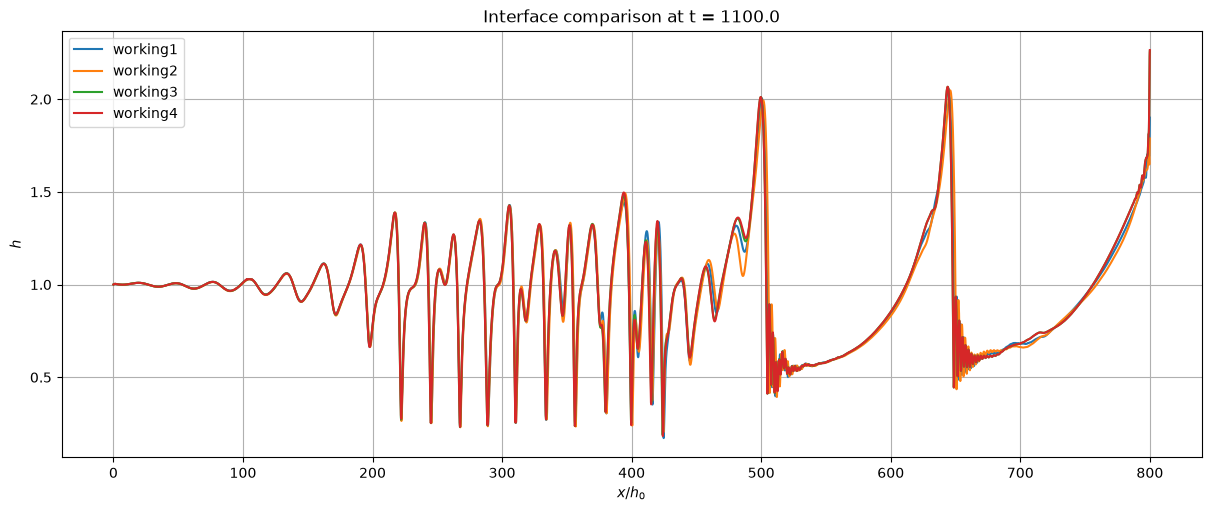

In [22]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

for case_name, case_data in all_case_data.items():

    ax.plot(
        case_data["x"],
        case_data["h"],
        label=case_name,
    )

ax.set_xlabel(r"$x/h_0$")
ax.set_ylabel(r"$h$")
ax.set_title(f"Interface comparison at t = {t}")
ax.grid(True)
ax.legend()

plt.show()

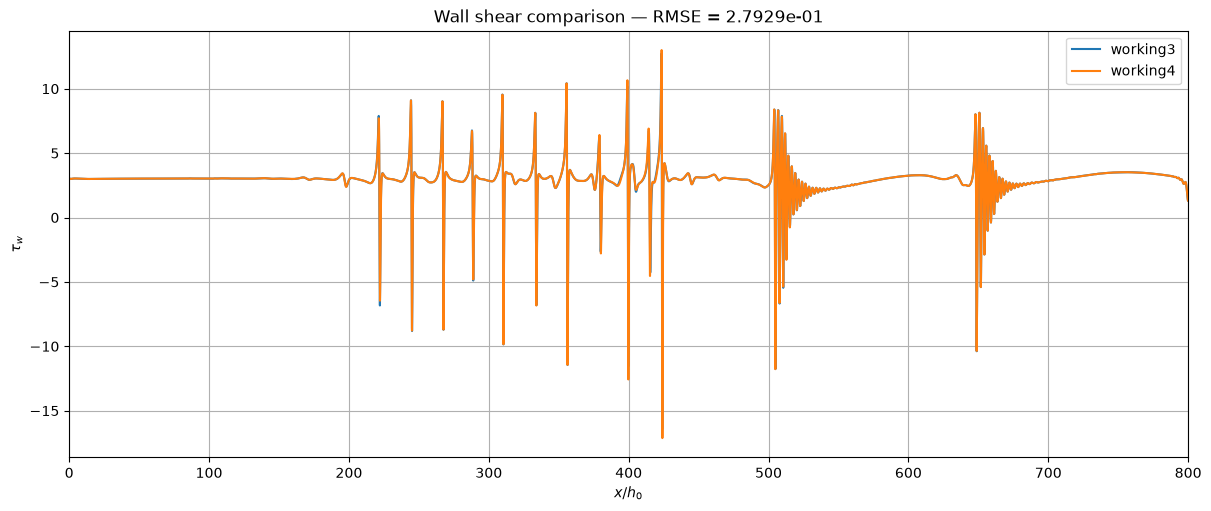

RMSE between working3 and working4 = 2.792882e-01


In [40]:
case_names_compare = [
    "working3",
    "working4",
]

xlim1 = 0
xlim2 = 800

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

for case_name in case_names_compare:

    data = all_case_data[case_name]

    ax.plot(
        data["x"],
        data["tau_w"],
        label=case_name,
    )

# RMSE between working3 and working4
tau_w_3 = all_case_data["working3"]["tau_w"]
tau_w_4 = all_case_data["working4"]["tau_w"]

valid = np.isfinite(tau_w_3) & np.isfinite(tau_w_4)

rmse = np.sqrt(np.mean((tau_w_3[valid] - tau_w_4[valid])**2))

ax.set_xlabel(r"$x/h_0$")
ax.set_ylabel(r"$\tau_w$")
ax.set_title(rf"Wall shear comparison — RMSE = {rmse:.4e}")
ax.set_xlim(xlim1, xlim2)
ax.grid(True)
ax.legend()

plt.show()

print(f"RMSE between working3 and working4 = {rmse:.6e}")

In [39]:
tau_w_3 = all_case_data["working3"]["tau_w"]
tau_w_4 = all_case_data["working4"]["tau_w"]

valid = np.isfinite(tau_w_3) & np.isfinite(tau_w_4)

error = tau_w_3[valid] - tau_w_4[valid]

rmse = np.sqrt(np.mean(error**2))

rms_reference = np.sqrt(np.mean(tau_w_4[valid]**2))

nrmse = rmse / rms_reference
print(f"RMSE  = {rmse:.6e}")
print(f"NRMSE = {nrmse:.6e}")
print(f"NRMSE = {100*nrmse:.2f}%")

relative_error_percent = np.full_like(tau_w_4, np.nan)

relative_error_percent[valid] = 100.0 * np.abs(tau_w_3[valid] - tau_w_4[valid]) / np.abs(tau_w_4[valid])

print(f"RE   = {np.nanmean(relative_error_percent):.4f}%")


RMSE  = 2.792882e-01
NRMSE = 8.551099e-02
NRMSE = 8.55%
RE   = 3.7912%


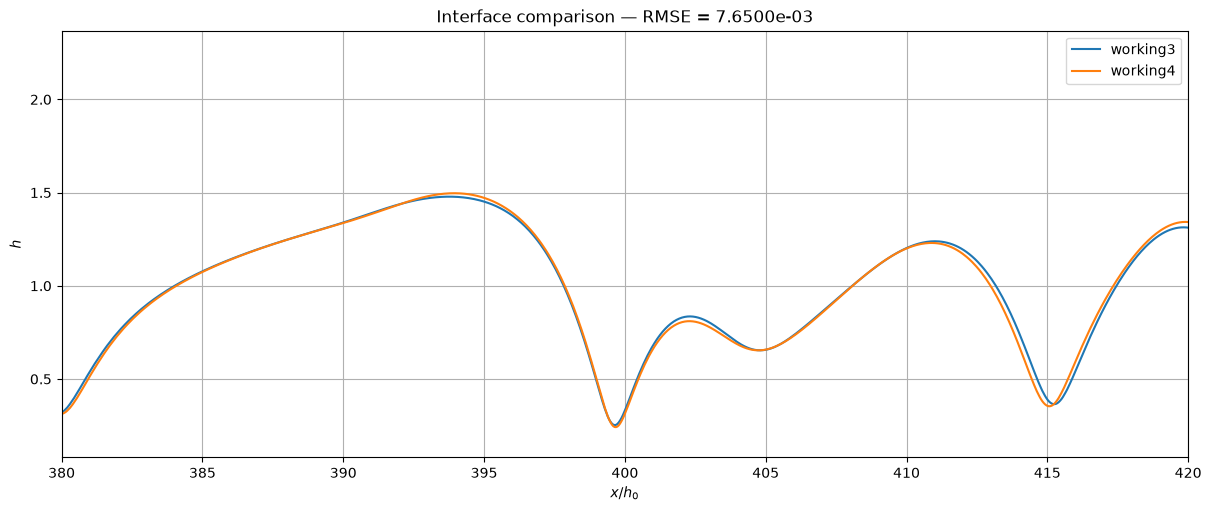

RMSE between working3 and working4 = 7.650037e-03


In [44]:
case_names_compare = [
    "working3",
    "working4",
]

xlim1 = 380
xlim2 = 420

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

for case_name in case_names_compare:

    data = all_case_data[case_name]

    ax.plot(
        data["x"],
        data["h"],
        label=case_name,
    )

# RMSE between working3 and working4
tau_w_3 = all_case_data["working3"]["h"]
tau_w_4 = all_case_data["working4"]["h"]

valid = np.isfinite(tau_w_3) & np.isfinite(tau_w_4)

rmse = np.sqrt(np.mean((tau_w_3[valid] - tau_w_4[valid])**2))

ax.set_xlabel(r"$x/h_0$")
ax.set_ylabel(r"$h$")
ax.set_title(rf"Interface comparison — RMSE = {rmse:.4e}")
ax.set_xlim(xlim1, xlim2)
ax.grid(True)
ax.legend()

plt.show()

print(f"RMSE between working3 and working4 = {rmse:.6e}")

In [36]:
tau_w_3 = all_case_data["working3"]["shape_factor"]
tau_w_4 = all_case_data["working4"]["shape_factor"]

valid = np.isfinite(tau_w_3) & np.isfinite(tau_w_4)

error = tau_w_3[valid] - tau_w_4[valid]

rmse = np.sqrt(np.mean(error**2))

rms_reference = np.sqrt(np.mean(tau_w_4[valid]**2))

nrmse = rmse / rms_reference

print(f"RMSE  = {rmse:.6e}")
print(f"NRMSE = {nrmse:.6e}")
print(f"NRMSE = {100*nrmse:.2f}%")

RMSE  = 1.499715e-02
NRMSE = 9.338096e-03
NRMSE = 0.93%


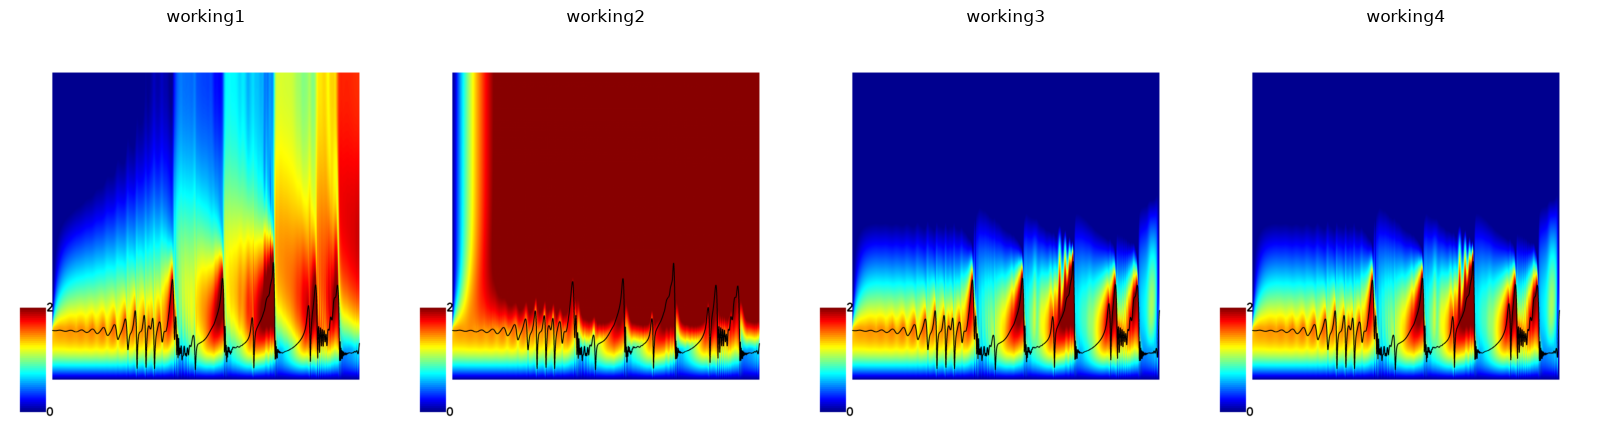

In [42]:
from PIL import Image
import matplotlib.pyplot as plt

image_filename = "ux-001000.png"

fig, ax = plt.subplots(
    1, 
    len(case_names),
    figsize=(16, 12),
    constrained_layout=True,
)

for i, case_name in enumerate(case_names):

    image_path = parent_dir / case_name / "images" / image_filename

    if not image_path.is_file():
        print(f"Missing image: {image_path}")
        ax[i].set_visible(False)
        continue

    image = Image.open(image_path)

    ax[i].imshow(image)
    ax[i].set_title(case_name)
    ax[i].axis("off")

plt.show()